# Cell counts and signal colocalization

This notebook is intentionally a thin driver. Image reading, Cellpose segmentation, channel matching, per-cell measurements, summaries, and file export are implemented in the `colocalize` package.

Before the first run, install the environment with `pip install -r requirements.txt` from the project directory.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from colocalize import (
    AnalysisConfig,
    MaxProjection,
    ReferenceSet,
    SignalChannel,
    build_dataset,
    inspect_inputs,
    run_analysis,
)

## Configuration

Channel numbers are zero-based. You may use metadata channel names instead (for example, `channel="DAPI"`) when the image format provides them. Add another `ReferenceSet` to segment a second reference definition with a different Cellpose model.

In [27]:
config = AnalysisConfig(
    input_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\20260701_GD_9911-9912-9913-9914-9915_20x_Cycle"),
    output_dir=Path(r"C:\Users\mzinn1\Desktop\DendrimerColocalization\RPBMS-GD_counts"),
    reference_sets=[
        ReferenceSet(
            name="BRN3A",
            channel=4,
            model="cpdino_BRN3A",  # Auto-downloads from Hugging Face if needed
            diameter=None,   # Set expected diameter in pixels, or leave automatic
        ),
    ],
    signal_channels=[
        SignalChannel(
            name="GD",
            channel=2,
            threshold_method="percentile",  # calibrated from point annotations
            threshold_value=99.5,
            positive_fraction_cutoff=0.05,
        ),
    ],
    transforms=[
        MaxProjection(),
        # Add other transforms here; they run in order.
    ],
    exclude=("Map_A01.oir",),
    device="auto",
    save_segmentation=True,  # Save grid + 4 panels for every input image
    # segmentation_output_dir=Path(r"C:\\path\\to\\segmentation-qc"),
)

## Verify inputs

Confirm the discovered files, normalized `C × Y × X` shapes, and channel names before running Cellpose.

In [28]:
inputs = inspect_inputs(config)
inputs

,source,path,shape_cyx,channels
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
5,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
6,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
7,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
8,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"
9,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,C:\Users\mzinn1\Desktop\DendrimerColocalizatio...,"(5, 1024, 1024)","(CH1, CH2, CH3, CH4, CH5)"


## Run analysis

The run writes `cells.csv`, `image_summary.csv`, and one label-mask TIFF per image/reference-set pair.

In [29]:
result = run_analysis(config)

In [30]:
display(result.images)
display(result.cells.head())

,source,reference_set,cell_count,total_cell_area_px,mean_cell_area_px,median_cell_area_px,signal_GD_positive_cell_count,mean_signal_GD_mean
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,280,49105,175.375000,173.5,4,180.530228
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,137,20917,152.678832,152.0,2,180.968200
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,675,108536,160.794074,160.0,3,230.374763
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,195,38935,199.666667,202.0,3,199.475421
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,374,69123,184.820856,186.0,4,209.448670
5,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,466,94585,202.972103,204.0,9,237.842653
6,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,389,65422,168.179949,166.0,3,366.363527
7,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,329,38467,116.920973,109.0,12,392.382779
8,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,292,46029,157.633562,157.0,5,235.860020
9,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,145,19429,133.993103,135.0,5,244.980685


,source,reference_set,cell_id,centroid_y,centroid_x,area_px,perimeter_px,equivalent_diameter_px,eccentricity,solidity,...,signal_GD_median,signal_GD_max,signal_GD_integrated,signal_GD_positive_area_px,signal_GD_positive_fraction,signal_GD_positive_cell,signal_GD_pearson_r,signal_GD_positive_jaccard,signal_GD_manders_m1_reference,signal_GD_manders_m2_signal
0,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,1,7.609467,604.159763,169,45.798990,14.668929,0.495532,0.965714,...,148.0,323.0,27058.0,0,0.0,False,0.072629,0.0,0.0,NaN
1,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,2,20.417910,991.925373,201,50.384776,15.997536,0.364983,0.957143,...,105.0,298.0,23075.0,0,0.0,False,-0.079581,0.0,0.0,NaN
2,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,3,28.718750,881.112500,160,45.213203,14.272993,0.577824,0.946746,...,126.0,276.0,20588.0,0,0.0,False,-0.067367,0.0,0.0,NaN
3,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,4,45.716667,865.866667,180,47.213203,15.138795,0.531181,0.967742,...,115.5,260.0,22916.0,0,0.0,False,0.083190,0.0,0.0,NaN
4,20260701_GD_9911-9912-9913-9914-9915_20x_A01_G...,BRN3A,5,46.722689,739.470588,119,38.970563,12.309163,0.610664,0.929688,...,131.0,304.0,15825.0,0,0.0,False,0.107339,0.0,0.0,NaN


## Optional segmentation quality check

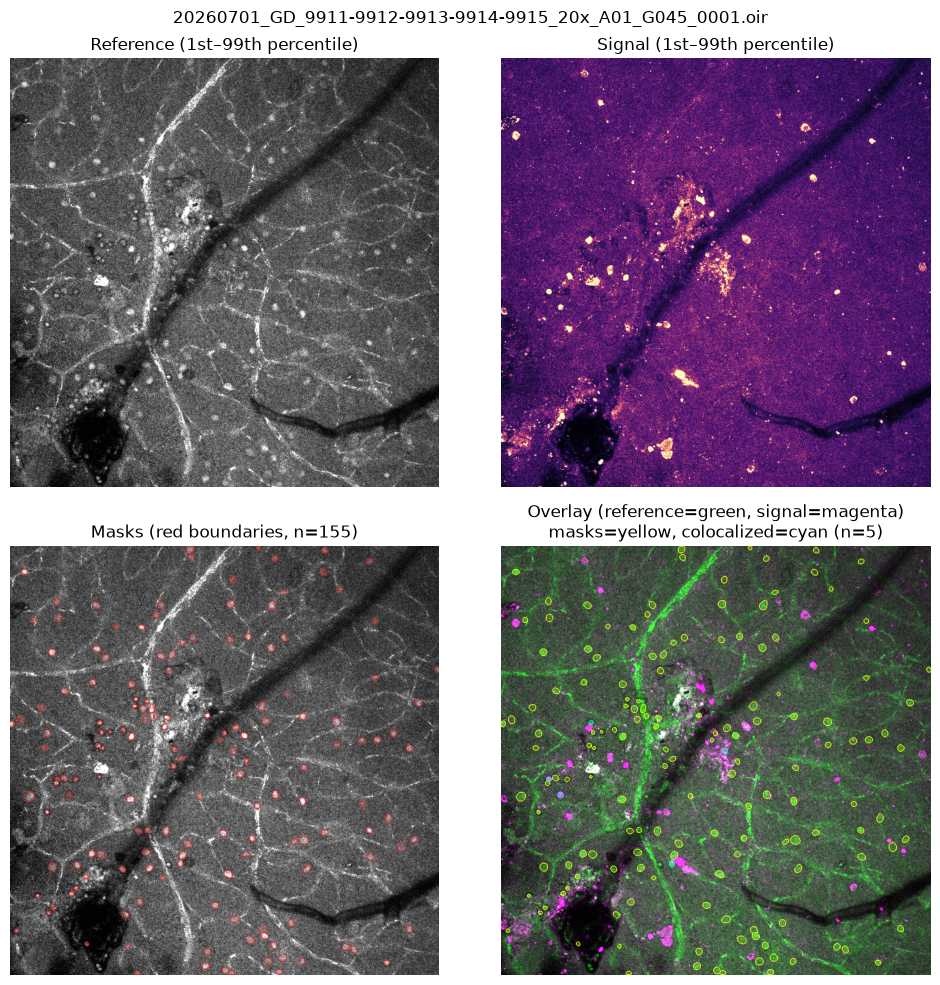

In [31]:
import tifffile
import importlib
from colocalize import visualization

importlib.reload(visualization)
img_number = 44
first_image = build_dataset(config, [inputs.iloc[img_number]["path"]])[0]
first_masks = tifffile.imread(result.mask_paths[img_number])
visualization.show_segmentation(
    first_image.channel(config.reference_sets[0].channel),
    first_masks,
    first_image.channel(config.signal_channels[0].channel),
    signal_spec=config.signal_channels[0],
    title=inputs.iloc[img_number]["source"],
);